# Benchmark Analysis — Reranker & Consensus Config Sweep

Standalone analysis block that **reloads and analyzes** the raw experiment results written by
`experimentation.ipynb` to `notebook/result/benchmark_raw.json`.

Run **Run All** from here on — no need to re-run the experiments (which take a long
time and call external LLM APIs). This first cell re-declares the small data structures
(`ConfigResult`, `QueryResult`) and the 27 eval queries that the downstream cells depend on,
so every cell below can execute top-to-bottom on its own.

In [51]:
%load_ext autoreload
%autoreload 2

import os, sys
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

REPO_ROOT = Path.home() / "Desktop" / "Multiagent_RAG_system"
os.chdir(str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT))

@dataclass
class ConfigResult:
    label: str
    reranker_on: bool
    n_generators: int
    expansion_strategy: str
    expander_on: bool
    results: list = field(default_factory=list)


@dataclass
class QueryResult:
    query: str
    latency_ms: float
    answer: str
    exp_str: str
    exp_on: str
    n_retrieved: int
    n_reranked: int
    reranked_chunk: list
    n_expanded: int
    n_claims: int
    n_supported: int
    claim_support: float
    confidence_final: float
    hallucination_risk: str
    error: Optional[str] = None
    # populated later
    faithfulness: Optional[float] = None
    answer_relevancy: Optional[float] = None
    context_precision: Optional[float] = None
    context_recall: Optional[float] = None
    grounding_score: Optional[float] = None  # LLM-judge, populated later


EVAL_QUERIES = [
        # rag_basics.txt
        "What is Retrieval-Augmented Generation?",
      "How does RAG reduce hallucinations in LLM outputs?",
     "What are the main components of a modern RAG pipeline?",
       "Why is RAG widely used in enterprise applications?",
        "What technique does RAG use to retrieve relevant information?",
        # vector_databases.txt
        "What is a vector database used for?",
        "How does Qdrant perform fast similarity search?",
        "What are some popular vector databases besides Qdrant?",
        "What distance metrics are commonly used in vector databases?",
        "What indexing algorithm does Qdrant use?",
        # llm_evaluation.txt
        "What is RAGAS and what does it measure?",
        "How does faithfulness differ from answer relevancy?",
        "What is a typical good faithfulness score for a RAG pipeline?",
        "How is hallucination risk typically assessed?",
        "What does context precision evaluate?",
        # cross_encoder_reranking.txt
        "What is cross-encoder reranking?",
        "How does two-stage retrieval work?",
        "Why are cross-encoders more accurate than bi-encoders?",
        "What cross-encoder models are mentioned?",
        "How does two-stage retrieval balance latency and accuracy?",
        # multi_agent_consensus.txt
        "What is multi-agent consensus in RAG?",
        "How does multi-agent consensus improve answer reliability?",
        "How many LLM instances are typically used in consensus?",
        "How is the best answer selected from multiple candidates?",
        "What additional verification step strengthens trust after consensus?",
        "Explain the full RAG retrieval-to-answer pipeline including reranking and consensus.",
        "How does INT4 quantization like GPTQ preserve accuracy compared to naive quantization?",
    ]

print(f"Eval set: {len(EVAL_QUERIES)} queries")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Eval set: 27 queries


# Analyzing the Result

In [52]:
# Transforming the trainsformed dataset into usable raw

import ast
import datetime
from typing import Any
from multiagent_rag_system.src.models.models import DocumentChunk, RerankedChunk


_ALLOWED_CALLS = {"RerankedChunk", "DocumentChunk", "datetime.datetime"}
_ALLOWED_ATTR_VALUES = {
    "datetime.timezone.utc": datetime.timezone.utc,
}


def _call_name(func_node):
    if isinstance(func_node, ast.Name):
        return func_node.id
    if isinstance(func_node, ast.Attribute):
        return f"{_call_name(func_node.value)}.{func_node.attr}"
    raise ValueError("Unrecognized call target")


def _eval_node(node):
    if isinstance(node, ast.List):
        return [_eval_node(el) for el in node.elts]

    if isinstance(node, ast.Call):
        func_name = _call_name(node.func)
        if func_name not in _ALLOWED_CALLS:
            raise ValueError(f"Disallowed call: {func_name}")
        
        args = [_eval_node(a) for a in node.args]
        kwargs = {kw.arg: _eval_node(kw.value) for kw in node.keywords}
        if func_name == "datetime.datetime":
            return datetime.datetime(*args, **kwargs)
        elif func_name == "RerankedChunk":
            return RerankedChunk(*args, **kwargs)
        elif func_name == "DocumentChunk":
            return DocumentChunk(*args, **kwargs)

    if isinstance(node, ast.Dict):
        return {_eval_node(k): _eval_node(v) for k, v in zip(node.keys, node.values)}

    if isinstance(node, ast.Constant):
        return node.value

    if isinstance(node, ast.UnaryOp) and isinstance(node.op, ast.USub):
        return -_eval_node(node.operand)

    if isinstance(node, ast.Attribute):
        dotted = _call_name(node)
        if dotted in _ALLOWED_ATTR_VALUES:
            return _ALLOWED_ATTR_VALUES[dotted]
        raise ValueError(f"Disallowed attribute: {dotted}")

    raise ValueError(f"Disallowed syntax: {type(node).__name__}")


def str_to_dict(reranked_chunks: Any) -> Any:
    """Parse a repr-string like '[RerankedChunk(...), ...]' into a
    list[RerankedChunk]. Pass the WHOLE string at once — do not
    iterate over it character by character. If it's already parsed
    (not a str), pass it through unchanged."""
    if not isinstance(reranked_chunks, str):
        return reranked_chunks
    tree = ast.parse(reranked_chunks, mode="eval")
    return _eval_node(tree.body)


#Main transform
def transform(raw_configs: dict) -> dict:
    """Convert the raw experiment-results dict into {label: ConfigResult},
    parsing each result's reranked_chunks string into real objects."""
    output = {}

    for index, dict_config in raw_configs.items():
        letter = index[0]
        cfg = dict_config.get("config")

        query_results = []
        for r in dict_config.get("results", []):
            try:
                parsed_chunks = str_to_dict(r["reranked_chunks"])
            except (SyntaxError, ValueError) as e:
                print(f"[warn] failed to parse reranked_chunks for "
                      f"query={r.get('query')!r} in {index!r}: {e}")
                parsed_chunks = r["reranked_chunks"]  # keep raw string on failure

            query_results.append(QueryResult(
                query=r["query"],
                latency_ms=r["latency_ms"],
                answer=r["answer"],
                exp_str=cfg["expander_strategy"],
                exp_on=cfg["expander_on"],
                n_retrieved=r["n_retrieved"],
                n_reranked=r["n_reranked"],
                n_expanded=r["n_expanded"],
                reranked_chunk=parsed_chunks,
                n_claims=r["n_claims"],
                n_supported=r["n_supported"],
                claim_support=r["claim_support"],
                confidence_final=r["confidence_final"],
                hallucination_risk=r["hallucination_risk"],
                error=r.get("error"),
                faithfulness=r["faithfulness"],
                answer_relevancy=r["answer_relevancy"],
                context_precision=r["context_precision"],
                context_recall=r["context_recall"],
                grounding_score=r["grounding_score"],
            ))

        output[index] = ConfigResult(
            label=letter,
            reranker_on=cfg["reranker_on"],
            n_generators=cfg["n_generators"],
            expansion_strategy=cfg["expander_strategy"],
            expander_on=cfg["expander_on"],
            results=query_results,
        )

    return output

In [53]:
# loading the data
import json
file_dir = "notebook/benchmark_raw1.json"
with open(file_dir, 'r') as file:
    data = json.load(file)

In [54]:
output= transform(data)

In [55]:
output

{'A: Reranker=ON, 3gen, exp_str=both, exp_on=ON': ConfigResult(label='A', reranker_on=True, n_generators=3, expansion_strategy='both', expander_on=True, results=[QueryResult(query='What is Retrieval-Augmented Generation?', latency_ms=29362.99, answer='Retrieval-Augmented Generation (RAG) is a technique that combines information retrieval with text generation [1]. In a RAG system, relevant document chunks are first retrieved from a knowledge base using vector similarity search and then fed as context to a large language model [1]. This grounding helps reduce hallucinations by requiring the LLM to answer from the provided passages rather than relying solely on parametric memory [1].', exp_str='both', exp_on=True, n_retrieved=17, n_reranked=5, reranked_chunk=[RerankedChunk(chunk=DocumentChunk(id='9d50eeca-6865-430f-89c4-4e4d8b3935cc', doc_id='c0cb8a1c-ff71-4ae3-a57b-7dfcee511023', content='Retrieval-Augmented Generation (RAG) is a technique that combines information retrieval with text ge

In [56]:
import pandas as pd
import numpy as np

def summarize(l:str, cr: ConfigResult) -> dict:
    latencies = [r.latency_ms for r in cr.results]
    finals = [r.confidence_final for r in cr.results]
    supports = [r.claim_support for r in cr.results]
    faithfulness = [r.faithfulness if r.faithfulness is not None else 0 for r in cr.results]
    answer_relevancy = [r.answer_relevancy if r.answer_relevancy is not None else 0 for r in cr.results]
    context_precision = [r.context_precision if r.context_precision is not None else 0 for r in cr.results]
    context_recall = [r.context_recall if r.context_recall is not None else 0 for r in cr.results]
    grounding = [r.grounding_score for r in cr.results if r.grounding_score is not None and r.grounding_score > 0]
    risks = [r.hallucination_risk for r in cr.results]
    n_supported_total = sum(r.n_supported for r in cr.results)
    n_claims_total = sum(r.n_claims for r in cr.results)
    errors = sum(1 for r in cr.results if r.error)

    return dict(
        config=l,
        reranker="ON" if cr.reranker_on else "OFF",
        generators=cr.n_generators,
        expansion_strg= cr.expansion_strategy,
        expansion_on = cr.expander_on,
        queries=len(cr.results),
        errors=errors,
        latency_avg_ms=np.mean(latencies),
        latency_median_ms=np.median(latencies),
        latency_p95_ms=np.percentile(latencies, 95),
        latency_min_ms=min(latencies),
        latency_max_ms=max(latencies),
        confidence_final_avg=np.mean(finals) if finals else 0.0,
        claim_support_avg=np.mean(supports),
        grounding_avg=np.mean(grounding) if grounding else 0.0,
        faithfulness_avg= np.mean(faithfulness) if faithfulness else 0.0,
        answer_relevancy_avg = np.mean(answer_relevancy) if answer_relevancy else 0.0,
        context_precision_avg = np.mean(context_precision) if context_precision else 0.0,
        context_recall_avg = np.mean(context_recall) if context_recall else 0.0,
        risk_low=risks.count("LOW"),
        risk_medium=risks.count("MEDIUM"),
        risk_high=risks.count("HIGH"),
        claims_supported=f"{n_supported_total}/{n_claims_total}",
        n_retrieved_avg=np.mean([r.n_retrieved for r in cr.results]),
        n_reranked_avg=np.mean([r.n_reranked for r in cr.results]),
    )

rows = [summarize(i, cr) for i, cr in output.items()]
summary_df = pd.DataFrame(rows)

display_cols = [
    "config", "reranker", "generators", "expansion_strg", "expansion_on",
    "latency_avg_ms", "latency_median_ms", "latency_p95_ms",
    "confidence_final_avg", "claim_support_avg",
    "faithfulness_avg","answer_relevancy_avg",
    "context_precision_avg", "context_recall_avg", "grounding_avg",
    "risk_low", "risk_medium", "risk_high", "claims_supported", "errors",
]
summary_df[display_cols].head()

,config,reranker,generators,expansion_strg,expansion_on,latency_avg_ms,latency_median_ms,latency_p95_ms,confidence_final_avg,claim_support_avg,faithfulness_avg,answer_relevancy_avg,context_precision_avg,context_recall_avg,grounding_avg,risk_low,risk_medium,risk_high,claims_supported,errors
0,"A: Reranker=ON, 3gen, exp_str=both, exp_on=ON",ON,3,both,True,11583.179259,10988.40,22486.100,0.579893,0.596300,0.983026,0.880141,0.925926,1.0,0.0,13,6,8,28/45,0
1,"B: Reranker=ON, 3gen, exp_str=hyde, exp_on=ON",ON,3,hyde,True,7276.992222,5770.15,16000.312,0.547574,0.543211,0.944033,0.856989,0.890122,1.0,0.0,11,7,9,28/48,0
2,"C: Reranker=ON, 3gen, exp_str=multi_query, exp...",ON,3,multi_query,True,6344.304444,5436.43,11400.403,0.555752,0.552470,0.956793,0.853826,0.861107,1.0,0.0,12,5,10,29/47,0
3,"D: Reranker=ON, 3gen, exp_str=off, exp_on=OFF",ON,3,off,False,9846.216667,7161.98,18986.828,0.563526,0.567900,0.975307,0.867778,0.856174,1.0,0.0,12,7,8,28/46,0
4,"E: Reranker=ON, 1gen, exp_str=both, exp_on=ON",ON,1,both,True,13984.077407,11981.58,24673.259,0.579667,0.594359,0.937656,0.873663,0.922837,1.0,0.0,11,9,7,30/47,0


In [10]:
# comparing query across the 16 different configurations
detail_rows = []
for i, q in enumerate(EVAL_QUERIES):
    row = {"#": i+1, "query": q[:60]}
    for label in output:
        qr = output[label].results[i]
        row[f"lat_{label[0]}"] = f"{qr.latency_ms:.0f}"
        row[f"conf_{label[0]}"] = f"{qr.confidence_final:.2f}"
        row[f"risk_{label[0]}"] = qr.hallucination_risk
        row[f"faithfulness_{label[0]}"]= f"{qr.faithfulness:.2f}"
        row[f"ans_relevance_{label[0]}"]=f"{qr.answer_relevancy:.2f}"
        row[f"ctx_precision_{label[0]}"]=f"{qr.context_precision:.2f}"
        row[f"ctx_recall_{label[0]}"] = f"{qr.context_recall:.2f}"
        row[f"gnd_{label[0]}"] = f"{qr.grounding_score:.2f}" if qr.grounding_score else "-"
    detail_rows.append(row)

detail_df = pd.DataFrame(detail_rows)
detail_df.head(3)

TypeError: unsupported format string passed to NoneType.__format__

## Post-hoc Analysis: best config by latency, accuracy & quality

Groups consume the already-loaded `output` dict (ConfigResult objects) and reuse `pd`, `np`, and `summary_df` from earlier cells.

### Group 1 - Load tidy long DataFrame

**Purpose:** collapse the ConfigResult structure (per-config -> list[QueryResult])
into a single tidy frame, one row per (config, query). This means that
every metric below (latency, RAGAS scores, risk, grounding) can be aggregated by
config OR by any single lever with one code path. We work from the already-parsed
in-memory `output` dict that we have above.

**Outcome:** One row per (config, query) for easy grouped analysis

In [57]:

rows = []
for label, cr in output.items():
    for qr in cr.results:
        rows.append({
            "config": label,
            "reranker": "ON" if cr.reranker_on else "OFF",
            "generators": cr.n_generators,
            "expansion": cr.expansion_strategy,
            "query": qr.query,
            "latency_ms": qr.latency_ms,
            "confidence_final": qr.confidence_final,
            "claim_support": qr.claim_support,
            "n_claims": qr.n_claims,
            "n_supported": qr.n_supported,
            "risk": qr.hallucination_risk,
            "faithfulness": qr.faithfulness,
            "answer_relevancy": qr.answer_relevancy,
            "context_precision": qr.context_precision,
            "context_recall": qr.context_recall,
            "grounding": qr.grounding_score,
        })
tidy = pd.DataFrame(rows)
print(f"tidy: {tidy.shape[0]} rows x {tidy.shape[1]} cols | "
      f"{tidy['query'].nunique()} unique queries | {tidy['config'].nunique()} configs")
tidy.head(10)

tidy: 432 rows x 16 cols | 27 unique queries | 16 configs


,config,reranker,generators,expansion,query,latency_ms,confidence_final,claim_support,n_claims,n_supported,risk,faithfulness,answer_relevancy,context_precision,context_recall,grounding
0,"A: Reranker=ON, 3gen, exp_str=both, exp_on=ON",ON,3,both,What is Retrieval-Augmented Generation?,29362.99,0.6326,0.6667,3,2,MEDIUM,1.0,0.8590,1.0000,1.0,None
1,"A: Reranker=ON, 3gen, exp_str=both, exp_on=ON",ON,3,both,How does RAG reduce hallucinations in LLM outp...,5023.12,0.5955,0.5000,2,1,MEDIUM,1.0,0.8689,1.0000,1.0,None
2,"A: Reranker=ON, 3gen, exp_str=both, exp_on=ON",ON,3,both,What are the main components of a modern RAG p...,16951.21,0.7655,1.0000,1,1,LOW,1.0,0.8884,0.7500,1.0,None
3,"A: Reranker=ON, 3gen, exp_str=both, exp_on=ON",ON,3,both,Why is RAG widely used in enterprise applicati...,22819.43,0.7875,1.0000,2,2,LOW,1.0,0.6828,0.3333,1.0,None
4,"A: Reranker=ON, 3gen, exp_str=both, exp_on=ON",ON,3,both,What technique does RAG use to retrieve releva...,10821.14,0.9893,1.0000,1,1,LOW,1.0,0.6857,1.0000,1.0,None
5,"A: Reranker=ON, 3gen, exp_str=both, exp_on=ON",ON,3,both,What is a vector database used for?,15669.18,0.5759,0.5000,2,1,MEDIUM,1.0,0.7877,1.0000,1.0,None
6,"A: Reranker=ON, 3gen, exp_str=both, exp_on=ON",ON,3,both,How does Qdrant perform fast similarity search?,18362.13,0.2264,0.0000,1,0,HIGH,1.0,0.8425,1.0000,1.0,None
7,"A: Reranker=ON, 3gen, exp_str=both, exp_on=ON",ON,3,both,What are some popular vector databases besides...,6117.37,0.7471,1.0000,1,1,LOW,1.0,0.8881,1.0000,1.0,None
8,"A: Reranker=ON, 3gen, exp_str=both, exp_on=ON",ON,3,both,What distance metrics are commonly used in vec...,11097.97,0.7852,1.0000,1,1,LOW,1.0,0.9774,1.0000,1.0,None
9,"A: Reranker=ON, 3gen, exp_str=both, exp_on=ON",ON,3,both,What indexing algorithm does Qdrant use?,12335.97,0.2381,0.0000,1,0,HIGH,1.0,0.8389,1.0000,1.0,None


### Group 2 - Grounding vs RAGAS discrepancy audit

**Note**: *Noticed the Grounding function(the LLM-as-a-judge) is buggy after the analysis. This audit is to check for any descrepancies, and if the function is usable.*

**Purpose:** audit the grounding grades before trusting them. These were produced by
the buggy grounding_eval (parse failures coerced to the worst 1.0), so low grades may be
a grading artifact, not true factual quality. 

So we inspect value distribution:
- the faithfulness x grounding cross-tab, 
- the spearman correlation vs the RAGAS metrics. 

**The decision follows from the numbers:** if grounding is near-flat (i.e. around ~1.5) and has zero correlation with faithfulness/relevancy, it is NOT a discriminative signal and will be excluded from the metrics used for configuration ranking.

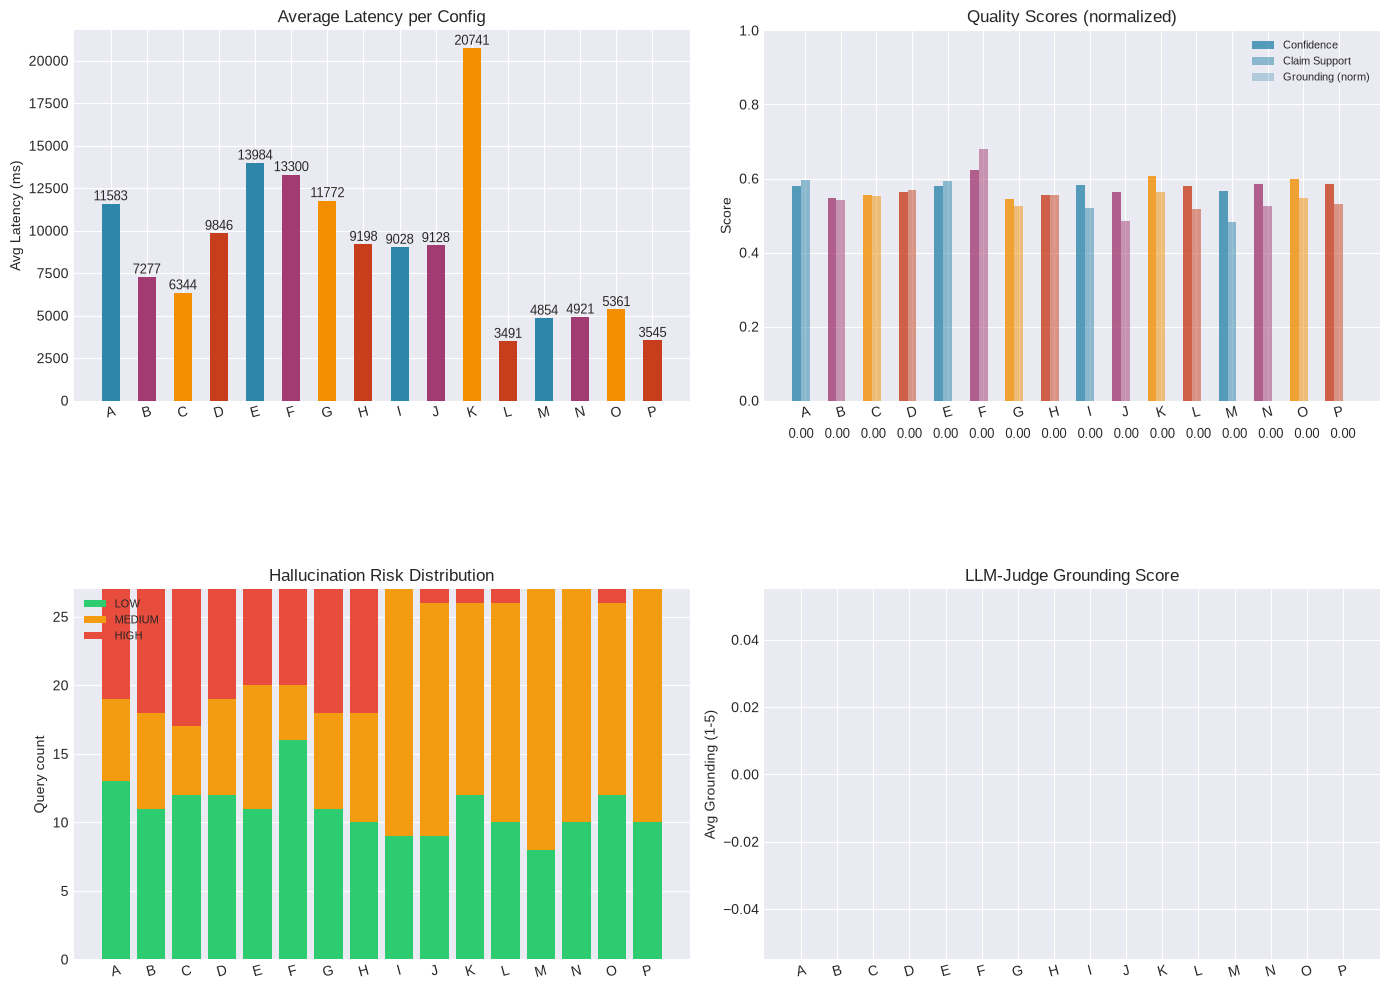

In [58]:
# Visualizations of latency, confidence comparision, risk distribution, and grounding scores across configurations
try:
    import matplotlib.pyplot as plt
    import matplotlib
    matplotlib.style.use("seaborn-v0_8-darkgrid")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"]
    labels = [cr.label for cr in output.values()]

    # Latency bar chart
    ax = axes[0, 0]
    x = np.arange(len(labels))
    ax.bar(x, summary_df["latency_avg_ms"], color=colors, width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([l[:12] for l in labels], rotation=15)
    ax.set_ylabel("Avg Latency (ms)")
    ax.set_title("Average Latency per Config")
    for i, v in enumerate(summary_df["latency_avg_ms"]):
        ax.text(i, v + 200, f"{v:.0f}", ha="center", fontsize=9)

    # Confidence comparison
    ax = axes[0, 1]
    width = 0.25
    x = np.arange(len(labels))
    ax.bar(x - width, summary_df["confidence_final_avg"], width, label="Confidence", color=colors, alpha=0.8)
    ax.bar(x, summary_df["claim_support_avg"], width, label="Claim Support", color=colors, alpha=0.5)
    ax.bar(x + width, summary_df["grounding_avg"] / 5, width, label="Grounding (norm)", color=colors, alpha=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels([l[:12] for l in labels], rotation=15)
    ax.set_ylabel("Score")
    ax.set_title("Quality Scores (normalized)")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.0)

    # Risk distribution stacked bar
    ax = axes[1, 0]
    low = summary_df["risk_low"]
    med = summary_df["risk_medium"]
    high = summary_df["risk_high"]
    ax.bar(x, low, label="LOW", color="#2ECC71")
    ax.bar(x, med, bottom=low, label="MEDIUM", color="#F39C12")
    ax.bar(x, high, bottom=low+med, label="HIGH", color="#E74C3C")
    ax.set_xticks(x)
    ax.set_xticklabels([l[:12] for l in labels], rotation=15)
    ax.set_ylabel("Query count")
    ax.set_title("Hallucination Risk Distribution")
    ax.legend(fontsize=8)

    # Grounding score bars
    ax = axes[1, 1]
    ax.bar(x, summary_df["grounding_avg"], color=colors, width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([l[:12] for l in labels], rotation=15)
    ax.set_ylabel("Avg Grounding (1-5)")
    ax.set_title("LLM-Judge Grounding Score")
    for i, v in enumerate(summary_df["grounding_avg"]):
        ax.text(i, v + 0.1, f"{v:.2f}", ha="center", fontsize=9)

    plt.tight_layout()
  #  plt.savefig(str(REPO_ROOT / "notebook" / "benchmark_results.png"), dpi=150, bbox_inches="tight")
    plt.show()
   # print("Chart saved to notebook/benchmark_results.png")
except ImportError:
    print("matplotlib not available — skipping charts.")

In [59]:
g = tidy["grounding"].dropna()

## Grounding score descriptive stats
print("=== (a) grounding value counts (existing grades, 1-5) ===")
print(g.value_counts().sort_index().to_string() if len(g) else "no grounding scores present")
if len(g):
    print(f"\nmean={g.mean():.2f}  count={len(g)}  n_missing={tidy['grounding'].isna().sum()}")

##Checking grounding vs faithfulness
print("\n=== (b) cross-tab faithfulness (rows) x grounding (cols) ===")
ct = tidy.dropna(subset=["grounding"]).groupby(["faithfulness", "grounding"]).size().unstack(fill_value=0)
print(ct.head(8).to_string() if len(ct) else "n/a")

=== (a) grounding value counts (existing grades, 1-5) ===
no grounding scores present

=== (b) cross-tab faithfulness (rows) x grounding (cols) ===
n/a


In [60]:
##checking the grounding vs RAG's Quality metrics correlation
corr_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall",
             "claim_support", "confidence_final", "latency_ms", "grounding"]
print("\n=== (c) spearman corr of quality metrics with grounding ===")
try:
    sc = tidy[corr_cols].corr(method="spearman")["grounding"].round(3)
except (TypeError, ValueError):
    sc = tidy[corr_cols].corr()["grounding"].round(3)
print(sc.to_string())


=== (c) spearman corr of quality metrics with grounding ===
faithfulness        NaN
answer_relevancy    NaN
context_precision   NaN
context_recall      NaN
claim_support       NaN
confidence_final    NaN
latency_ms          NaN
grounding           NaN


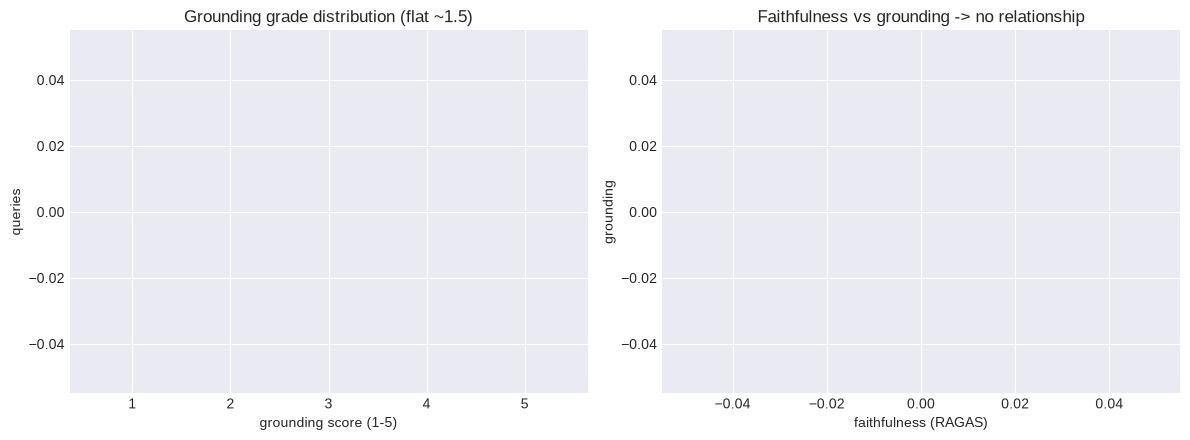

In [61]:
# Visualize the grounding anomaly: grade histogram + vs RAGAS faithfulness.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
g = tidy["grounding"].dropna()
vals, _ = np.histogram(g, bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5])
axes[0].bar([1, 2, 3, 4, 5], vals, color="#C73E1D")
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_xlabel("grounding score (1-5)")
axes[0].set_ylabel("queries")
axes[0].set_title("Grounding grade distribution (flat ~1.5)")

_m = tidy["grounding"].notna()
axes[1].scatter(tidy.loc[_m, "faithfulness"], g, alpha=0.5)
axes[1].set_xlabel("faithfulness (RAGAS)")
axes[1].set_ylabel("grounding")
axes[1].set_title("Faithfulness vs grounding -> no relationship")
plt.tight_layout()
plt.savefig("notebook/result/grounding_vs_faithfulness.png", dpi=150, bbox_inches="tight")
plt.show()

**Summary of Outcome:**
The analysis showed that the grounding is near_flat. Majority of the scores are in the 1.00 region. Plus, comparing this to the correlation score between grounding and the other metrics, the metrics are not correlated. This means grounding score is not discriminative (we can't make fine distinction between the output) and we're not using in our analysis and decision making. A buggy LLM-AS-A-JUDGE function.

**Verdict:** Grounding near-flat (~1.5) + near-zero correlation -> not discriminative; use as flag only.

### Group 3 - Latency characterization

**Purpose:** characterise latency per config. This latency is dominated by external LLM
API time (provider retries + grading/ragas sleeps), so the mean is pulled up by rare
tails (p95/max reach 40-125s). 

To order configs we therefore read median (stable) and
p95 (true tail a live system must survive), not the arithmetic mean.

Reason for choosing p95:
- The P95 strike a balance between p50 (which is the median and it's known to ignore tail issues) and p99 (usually noisy and prone to false alarm from rare spikes)

In [62]:
lat = tidy.groupby("config").agg(
    reranker=("reranker", "first"),
    generators=("generators", "first"),
    expansion=("expansion", "first"),
    n=("latency_ms", "size"),
    mean=("latency_ms", "mean"),
    median=("latency_ms", "median"),
    p95=("latency_ms", lambda s: float(np.percentile(s, 95))),
    max=("latency_ms", "max"),
).reset_index().sort_values("mean")
print(lat.round(1).to_string(index=False))
print("\nNote: latency includes external LLM API time (retries/sleeps); p95 tail matters more than the mean.")

                                               config reranker  generators   expansion  n    mean  median     p95      max
       L: Reranker=OFF, 3gen, exp_str=off, exp_on=OFF      OFF           3         off 27  3490.8  3377.7  4180.2   4434.7
       P: Reranker=OFF, 1gen, exp_str=off, exp_on=OFF      OFF           1         off 27  3544.8  3485.5  5200.0   6092.9
       M: Reranker=OFF, 1gen, exp_str=both, exp_on=ON      OFF           1        both 27  4854.0  4591.0  6475.0   6938.1
       N: Reranker=OFF, 1gen, exp_str=hyde, exp_on=ON      OFF           1        hyde 27  4921.1  4570.5  7301.2  10273.5
O: Reranker=OFF, 1gen, exp_str=multi_query, exp_on=ON      OFF           1 multi_query 27  5360.6  4904.2  8019.8  17099.3
 C: Reranker=ON, 3gen, exp_str=multi_query, exp_on=ON       ON           3 multi_query 27  6344.3  5436.4 11400.4  13889.7
        B: Reranker=ON, 3gen, exp_str=hyde, exp_on=ON       ON           3        hyde 27  7277.0  5770.2 16000.3  22719.4
       I: Rerank

**Visualization:** per-config latency. Median (bars) with p95 tail marker -- p95 is the tail
a live system must live within and is more discriminating than the inflated mean.

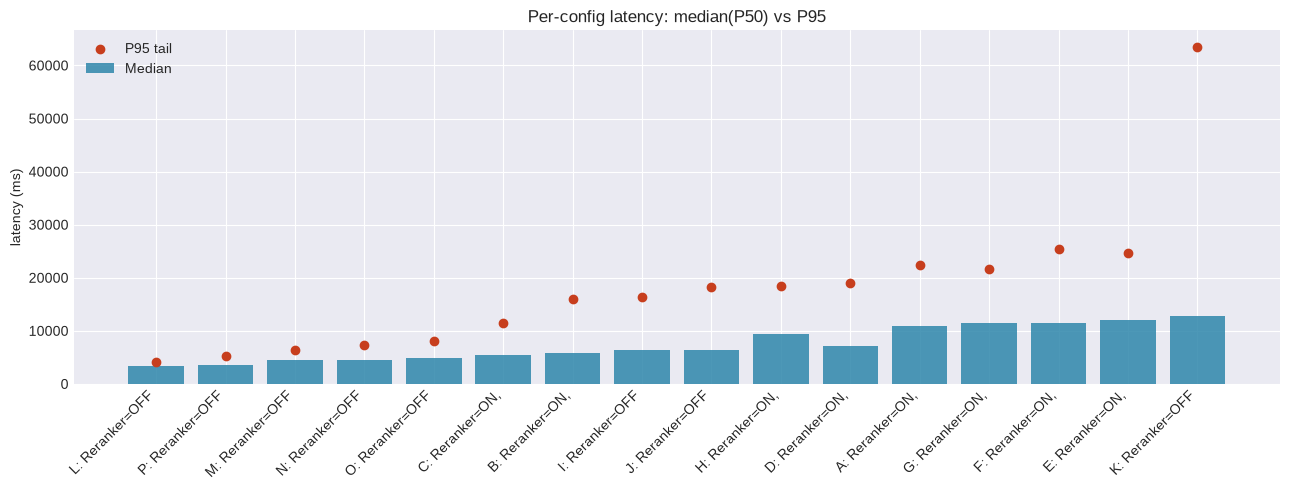

In [63]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(lat))
ax.bar(x, lat["median"], color="#2E86AB", alpha=0.85, label="Median")
ax.scatter(x, lat["p95"], color="#C73E1D", zorder=3, label="P95 tail")
ax.set_xticks(x)
ax.set_xticklabels([c[:15] for c in lat["config"]], rotation=45, ha="right")
ax.set_ylabel("latency (ms)")
ax.set_title("Per-config latency: median(P50) vs P95")
ax.legend()
plt.tight_layout()
plt.savefig("notebook/result/per_config_latency.png", dpi=150, bbox_inches="tight")
plt.show()

### Group 4 - Quality & safety profile

In [64]:
qcols = ["faithfulness", "answer_relevancy", "context_precision",
         "context_recall", "claim_support", "confidence_final"]  

## We've decided to exclude grounding from the quality summary, 
# because base on our previous analysis in Group2, it is non-discriminatory.

q = tidy.groupby("config")[qcols].mean().round(4)
print("=== quality (RAGAS + claim/confidence) per config ===")
print(q.to_string())

=== quality (RAGAS + claim/confidence) per config ===
                                                       faithfulness  answer_relevancy  context_precision  context_recall  claim_support  confidence_final
config                                                                                                                                                   
A: Reranker=ON, 3gen, exp_str=both, exp_on=ON                0.9830            0.8801             0.9259             1.0         0.5963            0.5799
B: Reranker=ON, 3gen, exp_str=hyde, exp_on=ON                0.9440            0.8570             0.8901             1.0         0.5432            0.5476
C: Reranker=ON, 3gen, exp_str=multi_query, exp_on=ON         0.9568            0.8538             0.8611             1.0         0.5525            0.5558
D: Reranker=ON, 3gen, exp_str=off, exp_on=OFF                0.9753            0.8678             0.8562             1.0         0.5679            0.5635
E: Reranker=ON, 1gen, 

In [65]:
rc = tidy.pivot_table(index="config", columns="risk", values="query", aggfunc="count", fill_value=0)
for c in ["LOW", "MEDIUM", "HIGH"]:
    if c not in rc.columns:
        rc[c] = 0
rc = rc[["LOW", "MEDIUM", "HIGH"]].astype(int)
rc["%_of_low"] = (rc["LOW"] / rc[["LOW", "MEDIUM", "HIGH"]].sum(axis=1)).round(3)

print("\n=== hallucination-risk profile ===")
print(rc.to_string())


=== hallucination-risk profile ===
risk                                                   LOW  MEDIUM  HIGH  %_of_low
config                                                                            
A: Reranker=ON, 3gen, exp_str=both, exp_on=ON           13       6     8     0.481
B: Reranker=ON, 3gen, exp_str=hyde, exp_on=ON           11       7     9     0.407
C: Reranker=ON, 3gen, exp_str=multi_query, exp_on=ON    12       5    10     0.444
D: Reranker=ON, 3gen, exp_str=off, exp_on=OFF           12       7     8     0.444
E: Reranker=ON, 1gen, exp_str=both, exp_on=ON           11       9     7     0.407
F: Reranker=ON, 1gen, exp_str=hyde, exp_on=ON           16       4     7     0.593
G: Reranker=ON, 1gen, exp_str=multi_query, exp_on=ON    11       7     9     0.407
H: Reranker=ON, 1gen, exp_str=off, exp_on=OFF           10       8     9     0.370
I: Reranker=OFF, 3gen, exp_str=both, exp_on=ON           9      18     0     0.333
J: Reranker=OFF, 3gen, exp_str=hyde, exp_on=ON     

**Observation:**
- reranker=ON configs (A-H) carry more HIGH flags than reranker=OFF (I-P);

We have to cross-check with factual RAGAS scores rather than the pipeline's own risk label.

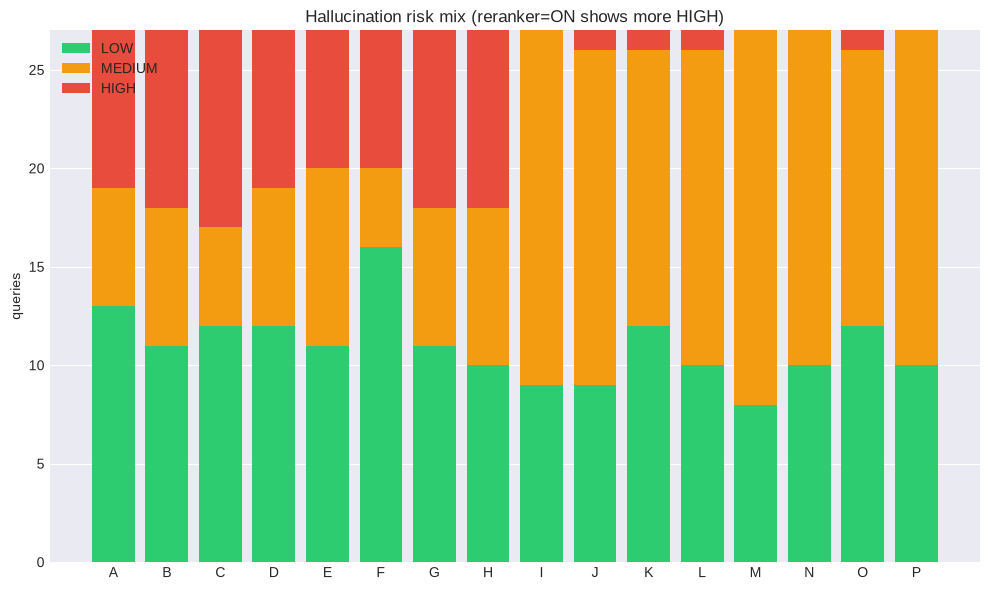

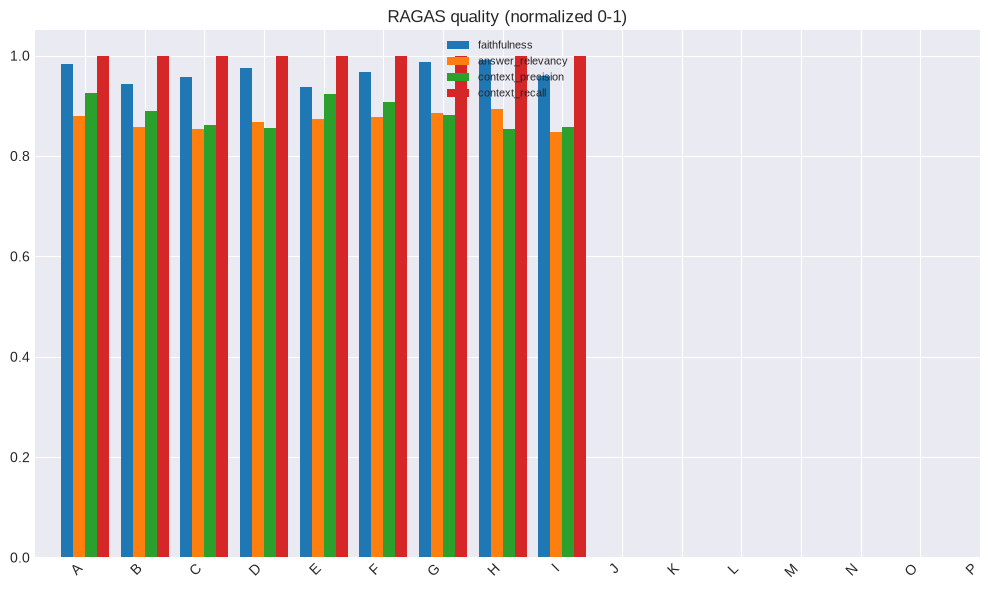

In [66]:
# Visualizations: (top) hallucination-risk mix per config; (bottom) normalized RAGAS means.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(figsize=(10, 6))
rr = rc[["LOW", "MEDIUM", "HIGH"]]
x = np.arange(len(rr))
axes.bar(x, rr["LOW"], color="#2ECC71", label="LOW")
axes.bar(x, rr["MEDIUM"], bottom=rr["LOW"], color="#F39C12", label="MEDIUM")
axes.bar(x, rr["HIGH"], bottom=rr["LOW"] + rr["MEDIUM"], color="#E74C3C", label="HIGH")
axes.set_xticks(x)
axes.set_xticklabels([c.split(":")[0] for c in rr.index], rotation=0)
axes.set_ylabel("queries")
axes.set_title("Hallucination risk mix (reranker=ON shows more HIGH)")
axes.legend()
plt.tight_layout()
plt.savefig("notebook/result/hallucination_risk_mix.png")
plt.show()

qn = q[["faithfulness", "answer_relevancy", "context_precision", "context_recall"]]
## already normalized to 0-1 for visual comparison
wsub = 0.2
fig, axes = plt.subplots(figsize=(10,6))
xl = np.arange(len(qn))
for j, col in enumerate(qn.columns):
    axes.bar(xl + (j - 1.5) * wsub, qn[col], width=wsub, label=col)
axes.set_xticks(xl)
axes.set_xticklabels([str(k).split(":")[0] for k in qn.index], rotation=45, ha="right")
axes.set_title("RAGAS quality (normalized 0-1)")
axes.legend(fontsize=8)
plt.tight_layout()
plt.savefig("notebook/result/ragas_quality.png")
plt.show()

### Group 5 - Main effects: which lever drives latency vs quality

**Purpose:** identify WHICH lever(reranker, query expander, n_generators) actually moves each metric, before optimising on configs.

Grouping by one lever at a time isolates the mean effect per level (reranker on/off;
generators 1/3; each expansion strategy). 

This will answer questions like: 
- Does adding a reranker raise latency but improve recall?" 
- Does multi_query add latency for no precision gain?" 

Surfacing the lever skew while not over-reading any single config.

In [67]:
mcols = ["latency_ms", "faithfulness", "answer_relevancy",
          "context_precision", "context_recall", "claim_support"]

for lever in ["reranker", "generators"]:
    g = tidy.groupby(lever)[mcols].mean().round(3)
    print(f"=== by {lever} ===")
    print(g.to_string())
    print()
    
print("=== by expansion strategy ===")
print(tidy.groupby("expansion")[mcols].mean().round(3).to_string())
print()
print("Read: which lever dominates latency vs retrieval/generation quality.")

=== by reranker ===
          latency_ms  faithfulness  answer_relevancy  context_precision  context_recall  claim_support
reranker                                                                                              
OFF         7633.554         0.958             0.848              0.858             1.0          0.521
ON         10413.141         0.968             0.873              0.887             1.0          0.577

=== by generators ===
            latency_ms  faithfulness  answer_relevancy  context_precision  context_recall  claim_support
generators                                                                                              
1             8366.851         0.971             0.882              0.891             1.0          0.555
3             9679.844         0.964             0.864              0.882             1.0          0.543

=== by expansion strategy ===
             latency_ms  faithfulness  answer_relevancy  context_precision  context_recall  cl

**Visualize main effects:** how each lever moves latency (top, lower=better) and
quality/relevance (bottom, higher=better). Groups lever levels into a grid.

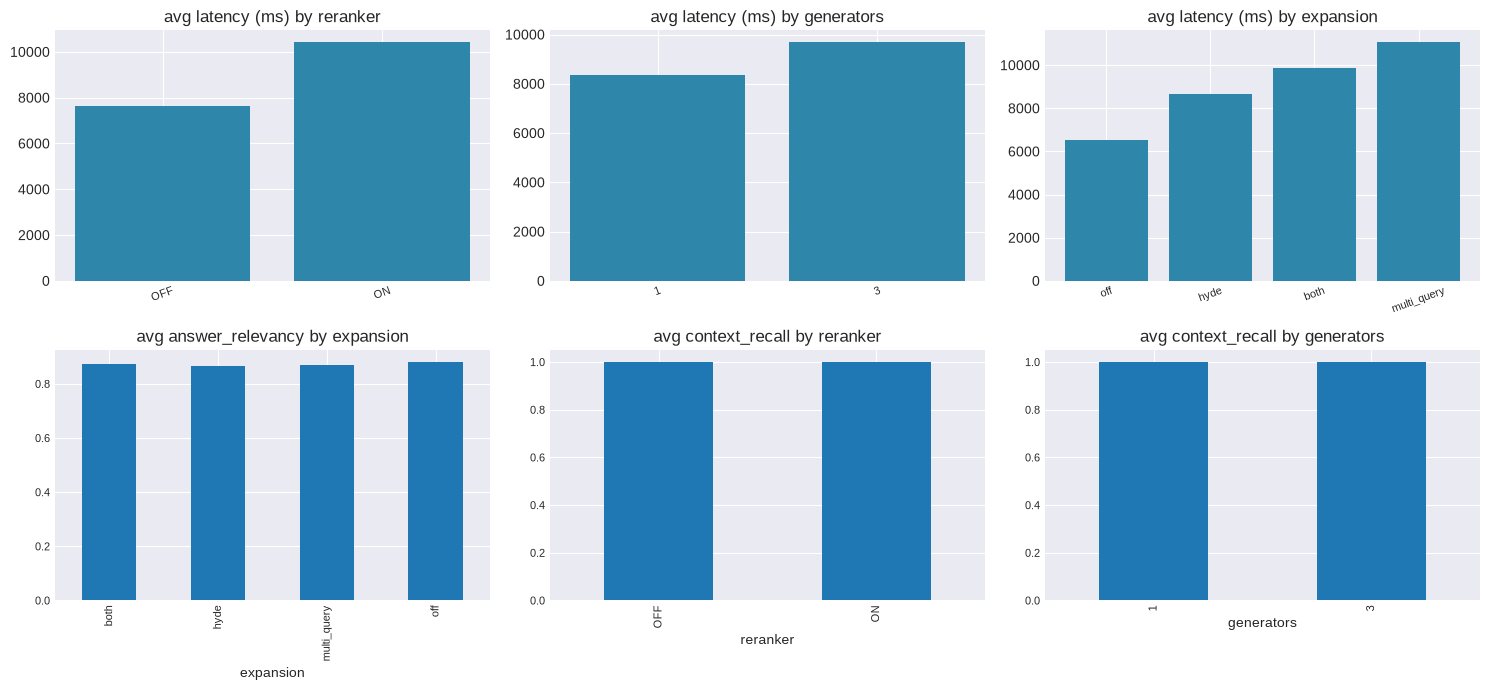

In [68]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
levers = ["reranker", "generators", "expansion"]
for j, lev in enumerate(levers):
    g_lat = tidy.groupby(lev)["latency_ms"].mean().sort_values()
    axes[0, j].bar(range(len(g_lat)), g_lat.values, color="#2E86AB")
    axes[0, j].set_xticks(range(len(g_lat)))
    axes[0, j].set_xticklabels([str(k) for k in g_lat.index], rotation=20, fontsize=8)
    axes[0, j].set_title(f"avg latency (ms) by {lev}")
    
grel = tidy.groupby("expansion")[["answer_relevancy"]].mean()
grel.plot(kind="bar", ax=axes[1, 0], legend=False, fontsize=8)
axes[1, 0].set_title("avg answer_relevancy by expansion")

grer = tidy.groupby("reranker")[["context_recall"]].mean()
grer.plot(kind="bar", ax=axes[1, 1], legend=False, fontsize=8)
axes[1, 1].set_title("avg context_recall by reranker")

ggen = tidy.groupby("generators")[["context_recall"]].mean()
ggen.plot(kind="bar", ax=axes[1, 2], legend=False, fontsize=8)
axes[1, 2].set_title("avg context_recall by generators")

fig.tight_layout()
plt.savefig("notebook/result/per_lever_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### Group 6 - Balanced composite (latency + quality) and Pareto frontier

**Purpose:** rank configs under the Balanced objective (latency + quality, equal weight).

 - rz() normalizes a column to [0,1] with higher=better; latency is inverted (lower=better).
 - `quality`     = mean of RAGAS/claim metrics.
 - `quality_all` = 0.8*quality + 0.2*low-risk-fraction, so safety contributes but does not dominate.
 - `composite`   = 0.5*latency_norm + 0.5*quality_norm.

**Pareto scan:** iterate configs in increasing latency, keep one if its quality exceeds the best
seen so far. Any kept config strictly improves quality over every faster config, so no kept
config is dominated on both axes at once (each sits on the latency/quality trade-off).

**Weight sweep:** re-rank under 0.3/0.5/0.7/0.9 latency weights so the recommended config is not a
single-weight coincidence.

In [69]:
def rz(s, high=True):
    lo, hi = s.min(), s.max()
    if hi <= lo:
        return s * 0
    return (s - lo) / (hi - lo) if high else 1 - (s - lo) / (hi - lo)

med = tidy.groupby("config")["latency_ms"].median()
qual = tidy.groupby("config")[["faithfulness", "answer_relevancy", "context_precision",
                               "context_recall", "claim_support"]].mean().mean(axis=1)
low_frac = tidy.groupby("config")["risk"].apply(lambda r: (r == "LOW").mean())

df = pd.DataFrame({"latency_med": med, "quality": qual, "low_frac": low_frac})
df["quality_all"] = 0.8 * rz(df["quality"]) + 0.2 * rz(df["low_frac"])
df["lat_n"] = rz(df["latency_med"], high=False)
df["composite"] = 0.5 * df["lat_n"] + 0.5 * df["quality_all"]
df = df.sort_values("composite", ascending=False).round(3)

print("=== ranked by balanced composite (0.5*latency + 0.5*quality) ===")
print(df[["latency_med", "quality", "lat_n", "composite"]].to_string())

pts = df.sort_values("latency_med", ascending=True)
bestQ, frontier = -1e9, []
for cfg, r in pts.iterrows():
    if r["quality"] > bestQ:
        frontier.append(cfg)
        bestQ = r["quality"]
print("\n=== Pareto-optimal (min latency vs max quality) ===")
print(frontier)

print("\n=== weight-sweep top-3: composite = w*lat + (1-w)*quality ===")
for w in [0.3, 0.5, 0.7, 0.9]:
    s = w * rz(df["latency_med"], False) + (1 - w) * rz(df["quality"])
    print(f"w={w}: {s.sort_values(ascending=False).head(3).index.tolist()}")

=== ranked by balanced composite (0.5*latency + 0.5*quality) ===
                                                       latency_med  quality  lat_n  composite
config                                                                                       
C: Reranker=ON, 3gen, exp_str=multi_query, exp_on=ON       5436.43    0.845  0.783      0.801
B: Reranker=ON, 3gen, exp_str=hyde, exp_on=ON              5770.15    0.847  0.748      0.772
D: Reranker=ON, 3gen, exp_str=off, exp_on=OFF              7161.98    0.853  0.601      0.718
I: Reranker=OFF, 3gen, exp_str=both, exp_on=ON             6320.97    0.837  0.690      0.709
H: Reranker=ON, 1gen, exp_str=off, exp_on=OFF              9475.51    0.858  0.357      0.576
F: Reranker=ON, 1gen, exp_str=hyde, exp_on=ON             11512.72    0.886  0.143      0.571
P: Reranker=OFF, 1gen, exp_str=off, exp_on=OFF             3485.49    0.531  0.989      0.568
L: Reranker=OFF, 3gen, exp_str=off, exp_on=OFF             3377.74    0.519  1.000      0

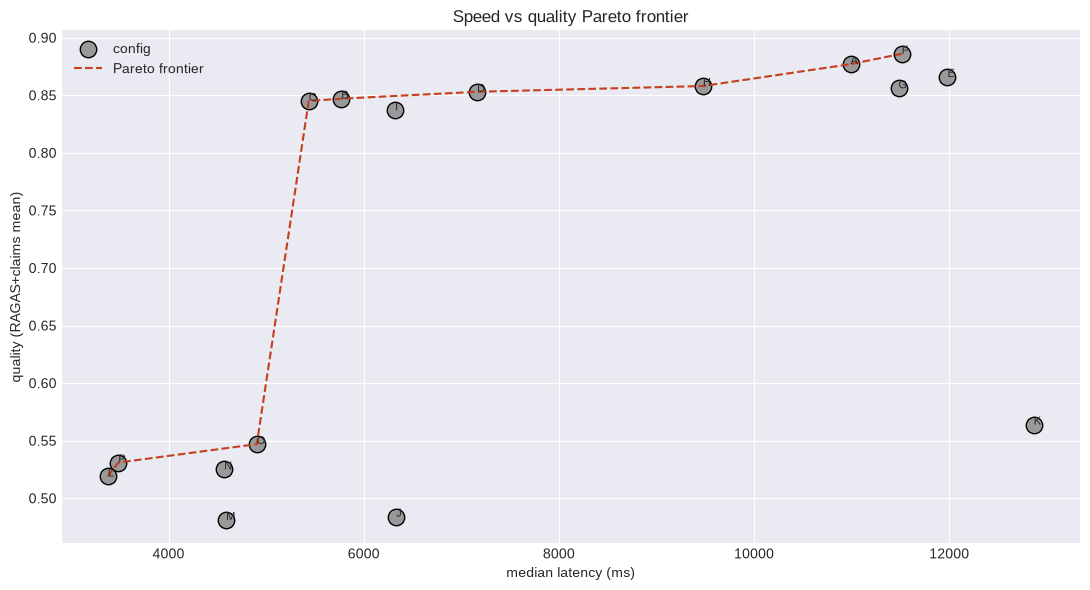

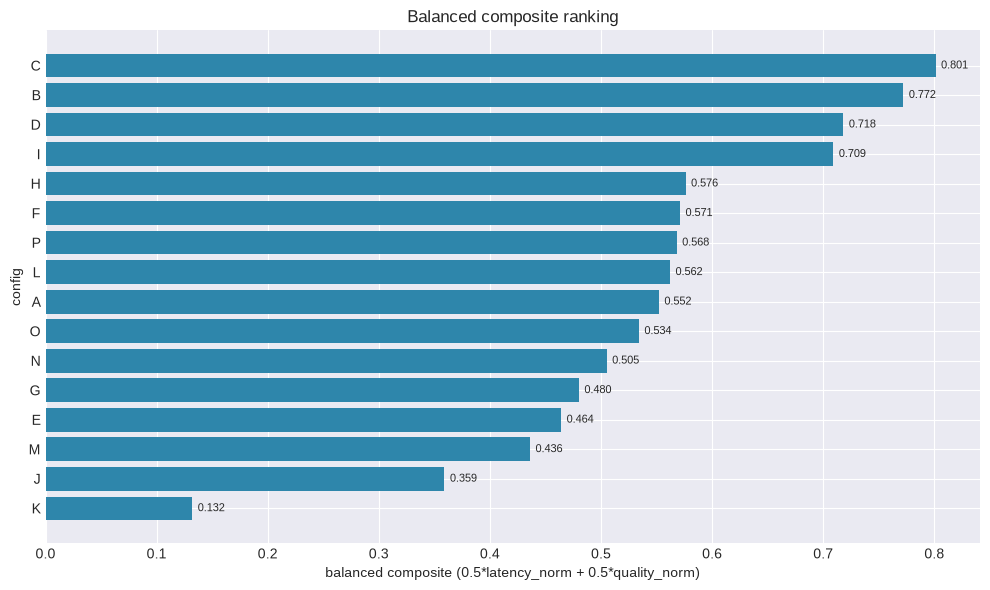

In [70]:
# Visualization: Pareto frontier (median latency x quality) and the balanced-composite
# ranking. `df` and `frontier` were built in Group 6 alongside.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 6))
order = df.sort_values("latency_med")
fx, fy = [], []
bestq = -1e9
for cfg, r in order.iterrows():
    if r["quality"] > bestq:
        fx.append(r["latency_med"]); fy.append(r["quality"]); bestq = r["quality"]
ax.scatter(df["latency_med"], df["quality"], s=140, c="#999", edgecolors="k", label="config", zorder=2)
ax.plot(fx, fy, "--", color="#C73E1D", label="Pareto frontier")
for cfg, r in order.iterrows():
    ax.annotate(cfg.split(":")[0], (r["latency_med"], r["quality"]), fontsize=8)
ax.set_xlabel("median latency (ms)")
ax.set_ylabel("quality (RAGAS+claims mean)")
ax.set_title("Speed vs quality Pareto frontier")
ax.legend()
plt.tight_layout()
plt.savefig("notebook/result/pareto_frontier.png", dpi=150, bbox_inches="tight")
plt.show()

# balanced-composite ranking
d2 = df.sort_values("composite").reset_index()
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(d2["config"].str.split(":").str[0], d2["composite"], color="#2E86AB")
ax.set_ylabel("config")
ax.set_xlabel("balanced composite (0.5*latency_norm + 0.5*quality_norm)")
ax.set_title("Balanced composite ranking")
for i, v in enumerate(d2["composite"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("notebook/result/pareto_frontier_and_composite.png", dpi=150, bbox_inches="tight")
plt.show()

### Group 7 - Final recommendation

**Purpose:** condense groups 3-6 into one actionable answer. `df` was built and sorted by
composite in Group 6, so the fastest / highest-quality / balanced picks are simple row
selections from it.

In [43]:
fast = df.sort_values("latency_med").iloc[0]
bestq = df.sort_values("quality").iloc[-1]
bestc = df.sort_values("composite", ascending=False).iloc[0]

print("=== recommendations ===")
print(f"Fastest (median): {df.loc[fast.name]['latency_med']:.0f} ms  ({fast.name})")
print(f"Highest quality:  {bestq.name}  (quality {bestq['quality']:.3f})")
print(f"Balanced 0.5/0.5: {bestc.name}  (composite {bestc['composite']:.3f})")

=== recommendations ===
Fastest (median): 3378 ms  (L: Reranker=OFF, 3gen, exp_str=off, exp_on=OFF)
Highest quality:  F: Reranker=ON, 1gen, exp_str=hyde, exp_on=ON  (quality 0.886)
Balanced 0.5/0.5: C: Reranker=ON, 3gen, exp_str=multi_query, exp_on=ON  (composite 0.801)


In [ ]:
# Export the converted csv file for reference and backup for external analysis

#summary_csv_path = REPO_ROOT / "notebook" / "result" /"benchmark_summary.csv"
#summary_df.to_csv(summary_csv_path, index=False, mode='a')
#print(f"Summary exported to {summary_csv_path}")

Summary exported to /home/emmanuel/Desktop/Multiagent_RAG_system/notebook/result/benchmark_summary.csv
